# Disaster effects prediction and insight with NSF

**steps**:
- load the disaster dataset and feats dataset
- combine them
- make a dataset for each disaster type
- for each type (starting with only one):
    * standardize and normalize the features
    * define the NSF model
    * train the model
    * inspect the resulting distribution
    * see the conditioning features effects

**dataset design**:
- one dataframe per event type
- time reference feat as ...
- no topographical feat as coords, not state/county
- geographical and natural feats for conditioning
- casualties and damages as y 

#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
from scipy import stats
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [2]:
DISASTER_DATA_DIR = Path("datasets")
COND_FEATS_PATH = Path("datasets/disasters_new_feats/all_new_feats.csv")

## Dataset Preparation

### Loading

In [6]:
disaster_df = utils.load_disaster_dataset(DISASTER_DATA_DIR)
feats_df = pd.read_csv(COND_FEATS_PATH)

In [7]:
print(disaster_df.columns)
print(feats_df.columns)

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='object')
Index(['PRECIPITATION', 'TMIN', 'TMAX', 'BEGIN_LAT', 'BEGIN_LON', 'ELEVATION',
       'SLOPE', 'COV_BARREN', 'COV_CULTIVATED', 'COV_

### Disaster processing

In [8]:
# reduce the disaster dataset to only the relevant columns
cols_to_keep = ["EVENT_TYPE", "BEGIN_DATE_TIME", "END_DATE_TIME", "INJURIES_DIRECT", "INJURIES_INDIRECT", "DEATHS_DIRECT",
                     "DEATHS_INDIRECT", "DAMAGE_PROPERTY", "DAMAGE_CROPS", "MAGNITUDE", "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON"] # "STATE", "FLOOD_CAUSE", "TOR_F_SCALE", "TOR_LENGTH", "TOR_WIDTH", "END_AZIMUTH", "END_LOCATION", 
disaster_df = disaster_df[cols_to_keep]

In [9]:
# remove unpredictable disaster types
unpredictable_events = ['High Surf', 'Sneakerwave', 'Seiche', 'Dense Smoke', 'Rip Current', 'Tropical Depression', 'Tsunami',
                    'Marine Tropical Depression', 'Volcanic Ashfall', 'Astronomical Low Tide', 'Dust Devil', 'Storm Surge/Tide']

disaster_df = disaster_df[~disaster_df['EVENT_TYPE'].isin(unpredictable_events)]

In [10]:
# aggregate events into broader categories
disaster_df['EVENT_GROUP'] = disaster_df['EVENT_TYPE'].replace(utils.disaster_events_group_map)
disaster_df.drop(columns=['EVENT_TYPE'], inplace=True)

In [11]:
# aggregate y cols into damages and casualties
disaster_df['DAMAGES'] = disaster_df['DAMAGE_PROPERTY'].apply(utils.damage_to_numeric) + disaster_df['DAMAGE_CROPS'].apply(utils.damage_to_numeric)
disaster_df['CASUALTIES'] = disaster_df['INJURIES_DIRECT'].fillna(0) + disaster_df['INJURIES_INDIRECT'].fillna(0) + disaster_df['DEATHS_DIRECT'].fillna(0) + disaster_df['DEATHS_INDIRECT'].fillna(0)

disaster_df.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=True)
disaster_df.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=True)

In [12]:
# change END_DATE_TIME to duration in hours
disaster_df['END_DATE_TIME'] = pd.to_datetime(disaster_df['END_DATE_TIME'])
disaster_df['BEGIN_DATE_TIME'] = pd.to_datetime(disaster_df['BEGIN_DATE_TIME'])
disaster_df['DURATION_HOURS'] = (disaster_df['END_DATE_TIME'] - disaster_df['BEGIN_DATE_TIME']).dt.total_seconds() / 3600
disaster_df.drop(columns=['END_DATE_TIME'], inplace=True)

C:\Users\xPica\AppData\Local\Temp\ipykernel_9628\2042865307.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  disaster_df['END_DATE_TIME'] = pd.to_datetime(disaster_df['END_DATE_TIME'])
C:\Users\xPica\AppData\Local\Temp\ipykernel_9628\2042865307.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  disaster_df['BEGIN_DATE_TIME'] = pd.to_datetime(disaster_df['BEGIN_DATE_TIME'])


In [13]:
# split MAGNITUDE into HAIL_SIZE and WIND_SPEED
disaster_df['HAIL_SIZE'] = disaster_df['MAGNITUDE'].where(disaster_df['EVENT_GROUP'] == 'Hail', 0)
disaster_df['WIND_SPEED'] = disaster_df['MAGNITUDE'].where(disaster_df['EVENT_GROUP'] != 'Hail', 0)
disaster_df['WIND_SPEED'] = disaster_df['WIND_SPEED'].fillna(0)
disaster_df.drop(columns=['MAGNITUDE'], inplace=True)

In [14]:
# encode datetime
disaster_df['TIME_DAY_SIN'] = np.sin(2 * np.pi * disaster_df['BEGIN_DATE_TIME'].dt.dayofyear / 365.25)
disaster_df['TIME_DAY_COS'] = np.cos(2 * np.pi * disaster_df['BEGIN_DATE_TIME'].dt.dayofyear / 365.25)
disaster_df['TIME_YEAR_NORM'] = (disaster_df['BEGIN_DATE_TIME'].dt.year - disaster_df['BEGIN_DATE_TIME'].dt.year.min()) / (disaster_df['BEGIN_DATE_TIME'].dt.year.max() - disaster_df['BEGIN_DATE_TIME'].dt.year.min())
disaster_df.drop(columns=['BEGIN_DATE_TIME'], inplace=True)

In [15]:
# remove coords cols (already have them in the feats dataset)
disaster_df = disaster_df.drop(columns=["BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON"])

In [16]:
disaster_df.head()

,EVENT_GROUP,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,WIND_SPEED,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM
0,Heavy Rain,2000.0,0,0.0,0.0,0.0,-0.244772,-0.969581,0.0
1,Wind,0.0,0,0.0,0.0,50.0,-0.244772,-0.969581,0.0
2,Wind,0.0,0,0.0,0.0,50.0,-0.261414,-0.965227,0.0
3,Wind,0.0,0,0.0,0.0,50.0,-0.126528,-0.991963,0.0
4,Wind,0.0,0,0.0,0.0,60.0,-0.126528,-0.991963,0.0


### Merging

In [17]:
df = pd.merge(disaster_df, feats_df, left_index=True, right_index=True)
df.head()

,EVENT_GROUP,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,WIND_SPEED,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
0,Heavy Rain,2000.0,0,0.0,0.0,0.0,-0.244772,-0.969581,0.0,1133.73,...,5.62,0.0,0.157,0.039,0.708,0.012,0.0,0.085,1248.1,237.1
1,Wind,0.0,0,0.0,0.0,50.0,-0.244772,-0.969581,0.0,1144.69,...,6.52,0.0,0.173,0.048,0.702,0.007,0.0,0.070,528.2,236.5
2,Wind,0.0,0,0.0,0.0,50.0,-0.261414,-0.965227,0.0,1433.45,...,39.69,0.0,0.056,0.006,0.936,0.001,0.0,0.001,431.3,363.6
3,Wind,0.0,0,0.0,0.0,50.0,-0.126528,-0.991963,0.0,1442.06,...,11.47,0.0,0.379,0.023,0.527,0.069,0.0,0.001,842.2,462.1
4,Wind,0.0,0,0.0,0.0,60.0,-0.126528,-0.991963,0.0,1327.57,...,15.72,0.0,0.405,0.016,0.567,0.006,0.0,0.005,1563.3,457.8


### Splitting by event type

In [18]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [19]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [20]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


## Model

In [21]:
df = event_group_dfs['Storm']

### Data normalization and Dataset creation

In [22]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [23]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [24]:
# targets log transformation
Y = np.log1p(Y)

In [25]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [26]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


In [27]:
# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

In [28]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

### Model definition

In [29]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256

In [30]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

In [ ]:
print("cuda") if torch.cuda.is_available() else print("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

In [32]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [33]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


### Model training

In [35]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []
        
history = TrainingHistory()

best_val_loss = np.inf
for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        loss = -flow(x).log_prob(y).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    flow.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    # Save history
    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]['lr'])
    
    print(
        f"Epoch {epoch:02d} | Time: {time.time() - t0:.2f}s : "
        f"Train NLL: {train_loss:.3f}, "
        f"Val NLL: {val_loss:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(flow.state_dict(), "./flow2_runs/best_flow.pt")

Epoch 00 | Time: 6.94s : Train NLL: -3.803, Val NLL: -3.734
Epoch 01 | Time: 7.00s : Train NLL: -3.895, Val NLL: -3.973
Epoch 02 | Time: 6.67s : Train NLL: -5.920, Val NLL: -3.693
Epoch 03 | Time: 6.33s : Train NLL: -3.923, Val NLL: -4.196
Epoch 04 | Time: 7.17s : Train NLL: -4.934, Val NLL: -3.551
Epoch 05 | Time: 7.15s : Train NLL: -3.820, Val NLL: -7.165
Epoch 06 | Time: 7.10s : Train NLL: -5.532, Val NLL: -6.152
Epoch 07 | Time: 6.89s : Train NLL: -4.864, Val NLL: -6.336
Epoch 08 | Time: 6.89s : Train NLL: -5.677, Val NLL: -7.347
Epoch 09 | Time: 6.85s : Train NLL: -5.167, Val NLL: -2.415
Epoch 10 | Time: 6.79s : Train NLL: -5.062, Val NLL: -4.636
Epoch 11 | Time: 6.62s : Train NLL: -4.786, Val NLL: -5.685
Epoch 12 | Time: 6.61s : Train NLL: -4.858, Val NLL: -4.545
Epoch 13 | Time: 6.73s : Train NLL: -6.150, Val NLL: -6.822
Epoch 14 | Time: 6.59s : Train NLL: -6.181, Val NLL: -6.457
Epoch 15 | Time: 6.69s : Train NLL: -6.271, Val NLL: -6.416
Epoch 16 | Time: 6.86s : Train NLL: -4.9

### Model Evaluation

In [36]:
flow.load_state_dict(torch.load("./flow2_runs/best_flow.pt"))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

C:\Users\xPica\AppData\Local\Temp\ipykernel_9628\2846061307.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  flow.load_state_dict(torch.load("./flow2_runs/best_flow.pt"))

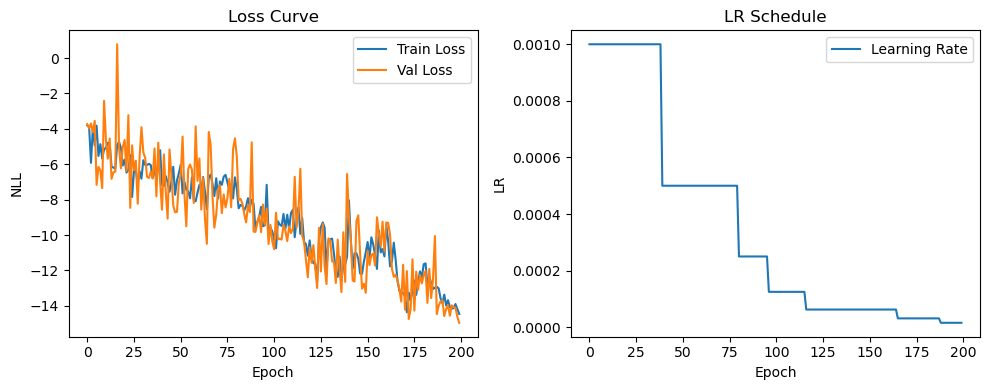

In [37]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


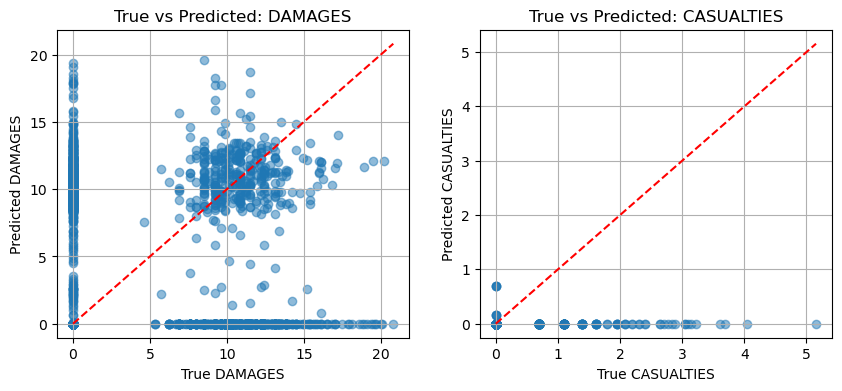

In [38]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

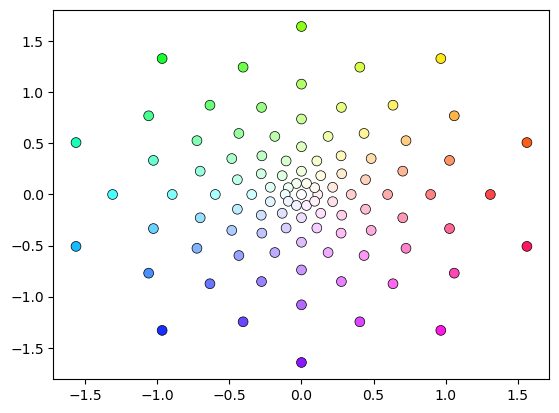

In [39]:
def get_gaussian_lattice(device='cpu', n_rings=10, n_points=10):
    """
    Generates a fixed 101-point lattice for 2D flow visualization.
    
    Structure:
    - 1 Center point (0,0)
    - n Rings of k points each
    - Radii based on Gaussian probability intervals
    - Alternating phase shift (0, 2pi/k) between rings
    
    Returns:
        z (Tensor): [1+n*k, 2] inputs for the flow inverse.
        colors (Array): [1+n*k, 3] RGB values for plotting the output.
    """
    points = []
    colors_hsv = []

    # --- 1. The Center (Point 0) ---
    points.append([0.0, 0.0])
    # Color: White (Saturation=0, Value=1)
    colors_hsv.append([0.0, 0.0, 1.0]) 

    # --- 2. The 10 Rings ---
    phase_shift = np.pi / n_points  # Alternating shift
    
    # Calculate radii corresponding to equidistant Gaussian probabilities
    # We slice probability space from 51% to 95%
    # This ensures we cover the 'meat' of the distribution and the tails
    probs = torch.linspace(0.5+0.45/n_rings, 0.95, n_rings)
    dist = torch.distributions.Normal(0, 1)
    radii = dist.icdf(probs) # Transform prob -> gaussian radius (sigma)
    max_r = radii[-1].item()

    for i, r in enumerate(radii):
        r = r.item()
        
        # Alternating phase: Even rings start at 0, Odd rings start at pi/20
        # (i starts at 0, so ring 1 is index 0)
        current_phase = phase_shift if (i % 2 != 0) else 0.0
        
        # Generate 10 angles for this ring
        angles = torch.linspace(0, 2*np.pi, n_points + 1)[:-1] + current_phase
        
        # Polar -> Cartesian
        x = r * torch.cos(angles)
        y = r * torch.sin(angles)
        
        # Append points
        ring_points = torch.stack([x, y], dim=1)
        points.append(ring_points)
        
        # --- Color Logic (Polar -> HSV) ---
        # Hue = Angle (normalized 0-1)
        # Saturation = Radius (normalized 0-1)
        # Value = 1.0 (Max brightness)
        
        # Normalize angles to [0, 1] for Hue
        # We use modulo to strictly keep it in range
        hues = (angles % (2*np.pi)) / (2*np.pi)
        
        # Saturation increases with radius (White center -> Vivid edge)
        saturation = r / (max_r * 1.1) # Divide by slightly more than max to avoid clipping
        saturations = torch.full_like(hues, saturation)
        
        values = torch.ones_like(hues) # Full brightness
        
        # Stack HSV for this ring
        ring_hsv = torch.stack([hues, saturations, values], dim=1)
        colors_hsv.append(ring_hsv)

    # --- 3. Assemble Final Tensors ---
    # Concatenate all lists into single tensors
    z_tensor = torch.cat([torch.tensor(points[:1]), torch.cat(points[1:])], dim=0)
    c_tensor_hsv = torch.cat([torch.tensor(colors_hsv[:1]), torch.cat(colors_hsv[1:])], dim=0)
    
    # SAFETY: Clamp HSV values to [0, 1] to prevent matplotlib errors
    c_tensor_hsv = torch.clamp(c_tensor_hsv, 0, 1)
    colors_rgb = mcolors.hsv_to_rgb(c_tensor_hsv.cpu().numpy())
    
    return z_tensor.float().to(device), colors_rgb

# --- Usage Example ---
# 1. Get the lattice
z_fixed, point_colors = get_gaussian_lattice()

# 3. Visualize
plt.scatter(z_fixed[:, 0], z_fixed[:, 1], c=point_colors, s=50, edgecolors='k', linewidth=0.5)
plt.show()

In [40]:
# Lattice-based inference: use fixed Gaussian lattice z_fixed instead of one Gaussian sample
# Assumes `z_fixed` and `point_colors` have been created with `get_gaussian_lattice()`.

def run_inference_and_plot_lattice(flow, test_loader, y_scaler, target_cols):
    """Run inference using a fixed Gaussian lattice in latent space.

    For each (x, y) in the test set, we:
    - Map all lattice points `z_fixed` through the inverse flow conditioned on x
    - Obtain many samples in y-space, then compute their mean and std per target
    - Collect these means as predictions and compare to true y, like in `run_inference_and_plot`.
    """
    flow.eval()

    y_true_all = []   # inverse-scaled ground truth
    y_mean_all = []   # inverse-scaled lattice means
    y_std_all = []    # inverse-scaled lattice stds

    # Move lattice to device once
    z = z_fixed.to(device)  # shape: [N, 2]

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            dist = flow(x_batch)  # conditional distribution p(y|x)

            # Broadcast lattice over the batch: [B, N, 2]
            B = x_batch.shape[0]
            z_expanded = z.unsqueeze(0).expand(B, -1, -1)

            # Invert the flow from lattice points in latent space to y-space
            y_samples = dist.transform.inv(z_expanded)  # [B, N, 2]

            # Inverse-scale all samples to original target space
            B, N, D = y_samples.shape
            y_samples_np = y_samples.reshape(B * N, D).cpu().numpy()
            y_samples_unscaled = y_scaler.inverse_transform(y_samples_np).reshape(B, N, D)

            # Mean and std over lattice dimension N for each sample in batch
            means = y_samples_unscaled.mean(axis=1)  # [B, 2]
            stds = y_samples_unscaled.std(axis=1)    # [B, 2]

            y_true_unscaled = y_scaler.inverse_transform(y_batch.cpu().numpy())

            y_true_all.append(y_true_unscaled)
            y_mean_all.append(means)
            y_std_all.append(stds)

    y_true_all = np.concatenate(y_true_all, axis=0)
    y_mean_all = np.concatenate(y_mean_all, axis=0)
    y_std_all = np.concatenate(y_std_all, axis=0)

    # Report overall average std per target
    avg_std = y_std_all.mean(axis=0)
    print(f"Average predicted std for {target_cols[0]} and {target_cols[1]}:", avg_std)

    # Scatter true vs lattice-mean predictions (like original function)
    plt.figure(figsize=(10, 4))

    # Target 0
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_all[:, 0], y_mean_all[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Lattice mean {target_cols[0]}")
    plt.title(f"True vs Lattice Mean: {target_cols[0]}")
    plt.plot(
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        [y_true_all[:, 0].min(), y_true_all[:, 0].max()],
        'r--'
    )
    plt.grid()

    # Target 1
    plt.subplot(1, 2, 2)
    plt.scatter(y_true_all[:, 1], y_mean_all[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Lattice mean {target_cols[1]}")
    plt.title(f"True vs Lattice Mean: {target_cols[1]}")
    plt.plot(
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        [y_true_all[:, 1].min(), y_true_all[:, 1].max()],
        'r--'
    )
    plt.grid()

    plt.tight_layout()
    plt.show()


## Result Analysis

In [41]:
X_test = X_test.to(device)
Y_test = Y_test.to(device)
pass

### Metrics & statistics #1

Negative Log-Likelihood

In [42]:
with torch.no_grad():
    X = X_test.to(device)
    Y = Y_test.to(device)
    test_nll = -flow(X).log_prob(Y).mean().item()

print(f"Test NLL: {test_nll:.3f}")

Test NLL: -15.091


In [43]:
def sample_predictions(flow, X, n_samples=1000):
    samples = []
    with torch.no_grad():
        for x in X:
            dist = flow(x.unsqueeze(0))
            s = dist.sample((n_samples,))  # [S,1,2]
            samples.append(s.squeeze(1))
    return torch.stack(samples)  # [N,S,2]

In [44]:
# Draw Posterior Predictive Samples
pred_samples = sample_predictions(flow, X_test[:200], n_samples=1000)

In [45]:
def invert_transform(samples):
    s = samples.reshape(-1,2).cpu().numpy()
    s = y_scaler.inverse_transform(s)
    s = np.expm1(s)
    return s.reshape(samples.shape)


In [46]:
# Undo Scaling and Log
pred_samples = invert_transform(pred_samples)
Y_true = invert_transform(Y_test[:200].unsqueeze(1)).squeeze(1)

#### Marginal Distribution Plots

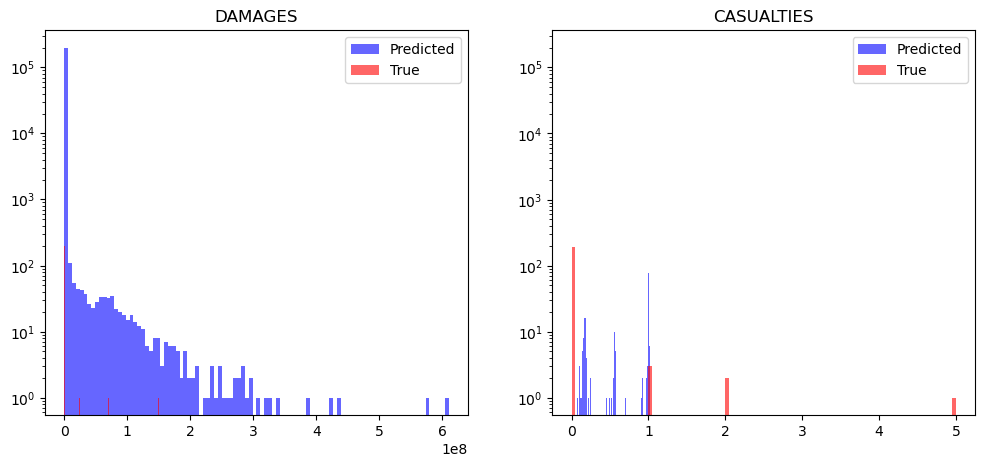

In [47]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(pred_samples[:,:,0].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,0], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("DAMAGES")
plt.legend()

plt.subplot(1,2,2)
plt.hist(pred_samples[:,:,1].flatten(), bins=100, alpha=0.6, color='blue', label='Predicted')
plt.hist(Y_true[:,1], bins=100, alpha=0.6, color='red', label='True')
plt.yscale("log")
plt.title("CASUALTIES")
plt.legend()

plt.show()


#### Joint Distribution (Correlation)

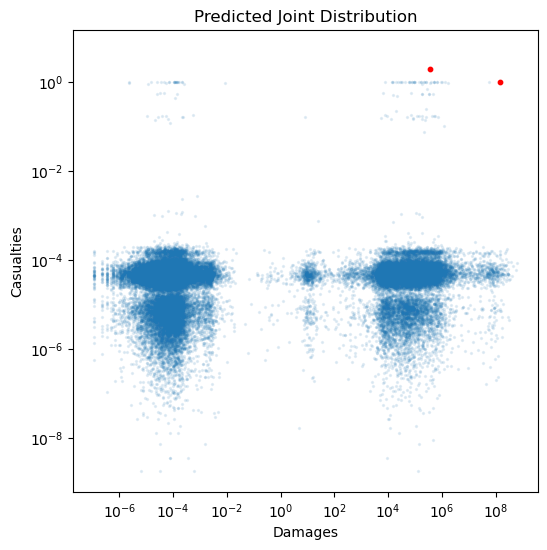

In [48]:
plt.figure(figsize=(6,6))
plt.scatter(
    pred_samples[:,:,0].flatten(),
    pred_samples[:,:,1].flatten(),
    s=2, alpha=0.1
)
plt.scatter(Y_true[:,0], Y_true[:,1], color="red", s=10)
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.xscale("log")
plt.yscale("log")
plt.title("Predicted Joint Distribution")
plt.show()


#### Coverage

In [49]:
lower = np.percentile(pred_samples, 5, axis=1)
upper = np.percentile(pred_samples, 95, axis=1)

inside = ((Y_true >= lower) & (Y_true <= upper))
coverage = inside.mean(axis=0)

print("90% coverage DAMAGES:", coverage[0])
print("90% coverage CASUALTIES:", coverage[1])


90% coverage DAMAGES: 0.97
90% coverage CASUALTIES: 0.97


#### Single-Event Posterior Plot

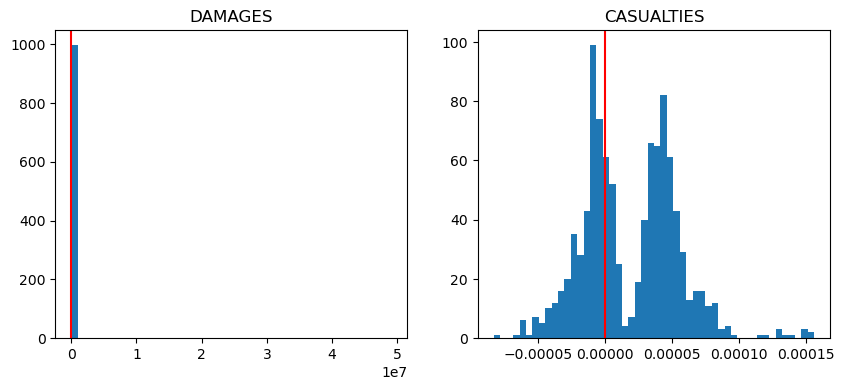

In [50]:
i = 5
s = pred_samples[i]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(s[:,0], bins=50)
plt.axvline(Y_true[i,0], color="red")
plt.title("DAMAGES")
plt.subplot(1,2,2)
plt.hist(s[:,1], bins=50)
plt.axvline(Y_true[i,1], color="red")
plt.title("CASUALTIES")
plt.show()


### Metrics & statistics #2

In [51]:
def sample_predictive(flow, x, n=10000):
    """
    x: torch tensor shape (1, X_DIM)
    returns samples in original scale: (n,2)
    """
    with torch.no_grad():
        dist = flow(x)
        samples = dist.sample((n,)).squeeze(1).cpu().numpy()

    samples = y_scaler.inverse_transform(samples)
    samples = np.expm1(samples)
    return samples


In [52]:
# random test sample
idx = np.random.randint(len(X_test))
x0 = X_test[idx:idx+1].to(next(flow.parameters()).device)
y_true = Y_test[idx].cpu().numpy()
y_true = np.expm1(y_scaler.inverse_transform(y_true.reshape(1,-1)))[0]

samples = sample_predictive(flow, x0)


#### 1. Joint Distribution Visualization

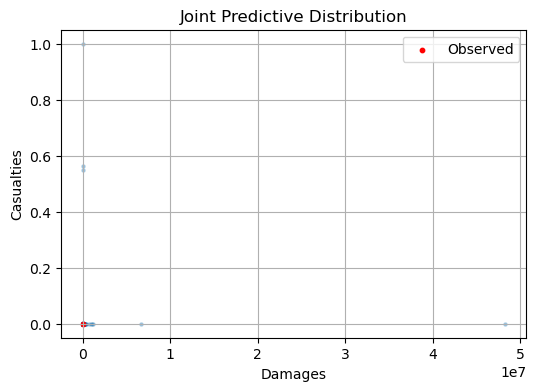

In [53]:
plt.figure(figsize=(6,4))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.3)
plt.scatter(y_true[0], y_true[1], color="red", s=10, label="Observed")
plt.xlabel("Damages")
plt.ylabel("Casualties")
plt.title("Joint Predictive Distribution")
plt.legend()
plt.grid()
plt.show()


#### 2. Marginal Distributions

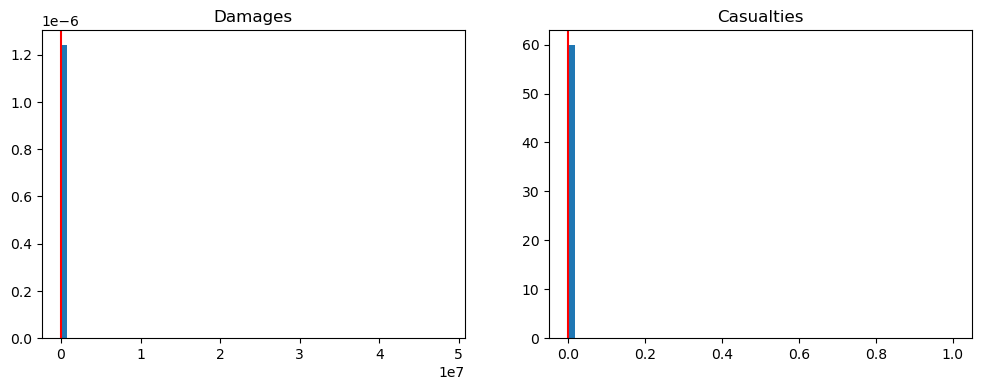

In [54]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(samples[:,0], bins=60, density=True)
axes[0].axvline(y_true[0], color="red")
axes[0].set_title("Damages")

axes[1].hist(samples[:,1], bins=60, density=True)
axes[1].axvline(y_true[1], color="red")
axes[1].set_title("Casualties")

plt.show()


#### 3. Output Correlation

In [55]:
corr = np.corrcoef(samples.T)[0,1]
print("Predicted correlation:", corr)


Predicted correlation: -0.00024381113686868522


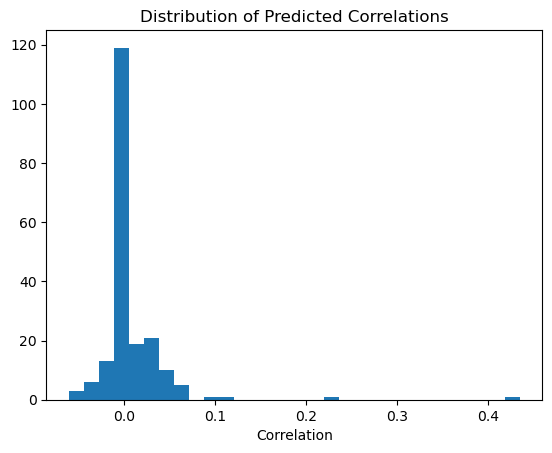

In [56]:
cors = []

for i in range(200):
    x = X_test[i:i+1].to(next(flow.parameters()).device)
    s = sample_predictive(flow, x, 1000)
    cors.append(np.corrcoef(s.T)[0,1])

plt.hist(cors, bins=30)
plt.xlabel("Correlation")
plt.title("Distribution of Predicted Correlations")
plt.show()


### Latent normality diagnostics


In [57]:
def collect_latents(flow, loader, device, max_samples=None):
    """Collect latent z samples for all (x, y) pairs in a DataLoader.

    Args:
        flow: Trained conditional flow model.
        loader: DataLoader yielding (x, y) batches in standardized space.
        device: Torch device.
        max_samples: Optional int, subsample to at most this many points.

    Returns:
        z: Tensor of shape (N, D) on CPU.
    """
    flow.eval()
    zs = []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            dist = flow(x_batch)
            # Forward transform: data space y -> latent space z
            z_batch = dist.transform(y_batch)

            zs.append(z_batch.cpu())

    z = torch.cat(zs, dim=0)

    if max_samples is not None and z.shape[0] > max_samples:
        idx = torch.randperm(z.shape[0])[:max_samples]
        z = z[idx]

    return z


In [58]:
def test_multivariate_normality(z_samples, label=""):
    """KS test of squared L2 norms vs Chi-square(D).

    z_samples: (N, D) tensor on any device.
    """
    D = z_samples.shape[1]
    squared_norms = (z_samples ** 2).sum(dim=1).cpu().numpy()

    ks_stat, p_value = stats.kstest(squared_norms, "chi2", args=(D,))

    prefix = f"[{label}] " if label else ""
    print(f"{prefix}Chi-Squared Fit: KS-Stat={ks_stat:.4f}, p-value={p_value:.4e}")
    if p_value < 0.05:
        print(f"{prefix}>> REJECT: The joint distribution is statistically NOT Standard Normal.")
    else:
        print(f"{prefix}>> ACCEPT: The joint distribution looks Standard Normal.")


def test_dimension_wise(z_samples, label=""):
    """Dimension-wise KS and Jarque–Bera tests vs standard normal.

    Prints per-dimension KS and JB p-values and a count of KS failures.
    """
    N, D = z_samples.shape
    prefix = f"[{label}] " if label else ""

    print(f"{prefix}Checking dimensions (N={N}, D={D})...")
    failures = 0
    for i in range(D):
        data = z_samples[:, i].cpu().numpy()

        # KS test vs standard normal
        ks_stat, ks_p = stats.kstest(data, "norm")

        # Jarque–Bera test (skewness & kurtosis)
        jb_stat, jb_p = stats.jarque_bera(data)

        if ks_p < 0.05:
            failures += 1

        print(
            f"{prefix}Dim {i}: KS p={ks_p:.3e}, JB p={jb_p:.3e} "
            f"(KS-stat={ks_stat:.3f}, JB-stat={jb_stat:.3f})"
        )

    print(f"{prefix}Dimensions failing KS normality (p < 0.05): {failures}/{D}")


In [59]:
# Collect latent samples for training and test sets

z_train = collect_latents(flow, train_loader, device, max_samples=50000)
z_test = collect_latents(flow, test_loader, device, max_samples=50000)

print(f"z_train shape: {z_train.shape}")
print(f"z_test shape:  {z_test.shape}")

print("\n=== Multivariate normality (Chi-square KS) ===")
test_multivariate_normality(z_train, label="train")
test_multivariate_normality(z_test, label="test")

print("\n=== Dimension-wise normality (KS + Jarque–Bera) ===")
test_dimension_wise(z_train, label="train")
test_dimension_wise(z_test, label="test")


z_train shape: torch.Size([39056, 2])
z_test shape:  torch.Size([8369, 2])

=== Multivariate normality (Chi-square KS) ===
[train] Chi-Squared Fit: KS-Stat=0.5733, p-value=0.0000e+00
[train] >> REJECT: The joint distribution is statistically NOT Standard Normal.
[test] Chi-Squared Fit: KS-Stat=0.5751, p-value=0.0000e+00
[test] >> REJECT: The joint distribution is statistically NOT Standard Normal.

=== Dimension-wise normality (KS + Jarque–Bera) ===
[train] Checking dimensions (N=39056, D=2)...
[train] Dim 0: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.407, JB-stat=237778.766)
[train] Dim 1: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.577, JB-stat=71183890.997)
[train] Dimensions failing KS normality (p < 0.05): 2/2
[test] Checking dimensions (N=8369, D=2)...
[test] Dim 0: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.412, JB-stat=38116.999)
[test] Dim 1: KS p=0.000e+00, JB p=0.000e+00 (KS-stat=0.577, JB-stat=10705605.028)
[test] Dimensions failing KS normality (p < 0.05): 2/2


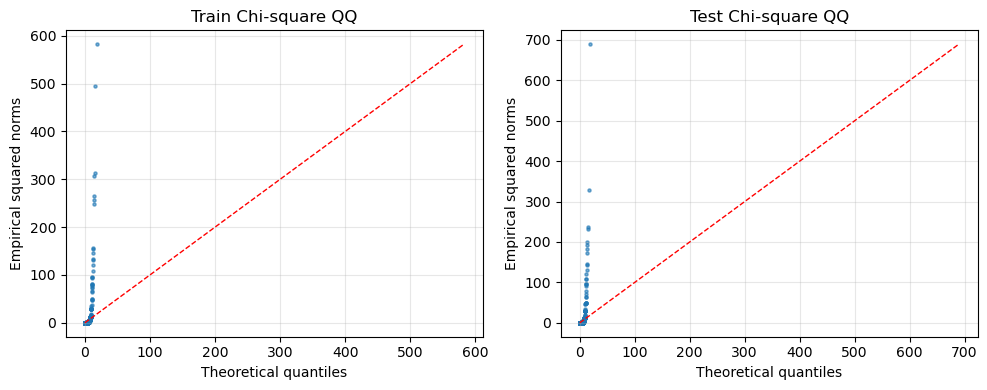

In [60]:
# Chi-squared QQ plots for joint normality

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, z, label in zip(axes, [z_train, z_test], ["Train", "Test"]):
    D = z.shape[1]
    r2 = (z ** 2).sum(dim=1).cpu().numpy()

    # Subsample for speed if very large
    max_points = 5000
    if r2.shape[0] > max_points:
        idx = np.random.choice(r2.shape[0], size=max_points, replace=False)
        r2 = r2[idx]

    r2_sorted = np.sort(r2)
    probs = (np.arange(1, len(r2_sorted) + 1) - 0.5) / len(r2_sorted)
    theo = stats.chi2.ppf(probs, df=D)

    ax.scatter(theo, r2_sorted, s=5, alpha=0.6)
    maxv = max(theo.max(), r2_sorted.max())
    ax.plot([0, maxv], [0, maxv], "r--", linewidth=1.0)
    ax.set_title(f"{label} Chi-square QQ")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical squared norms")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


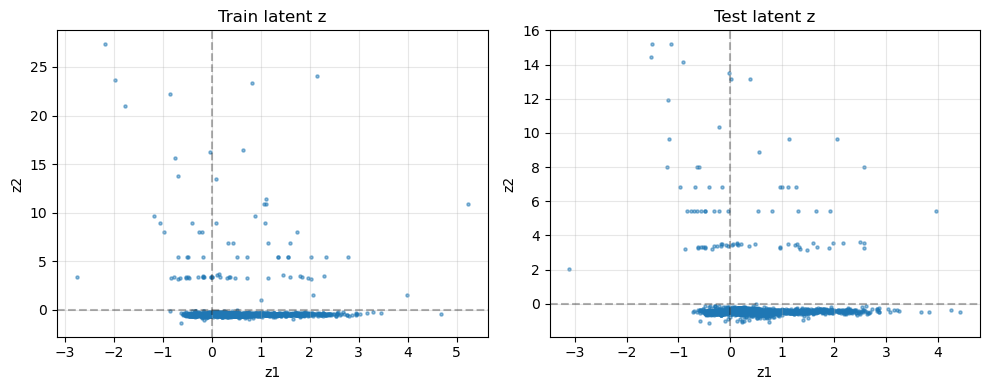

In [61]:
# 2D latent scatter plots for train and test

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

max_points = 5000

for ax, z, label in zip(axes, [z_train, z_test], ["Train", "Test"]):
    z_np = z.cpu().numpy()
    if z_np.shape[0] > max_points:
        idx = np.random.choice(z_np.shape[0], size=max_points, replace=False)
        z_np = z_np[idx]

    ax.scatter(z_np[:, 0], z_np[:, 1], s=5, alpha=0.5)
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.axvline(0, color="k", linestyle="--", alpha=0.3)
    ax.set_title(f"{label} latent z")
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


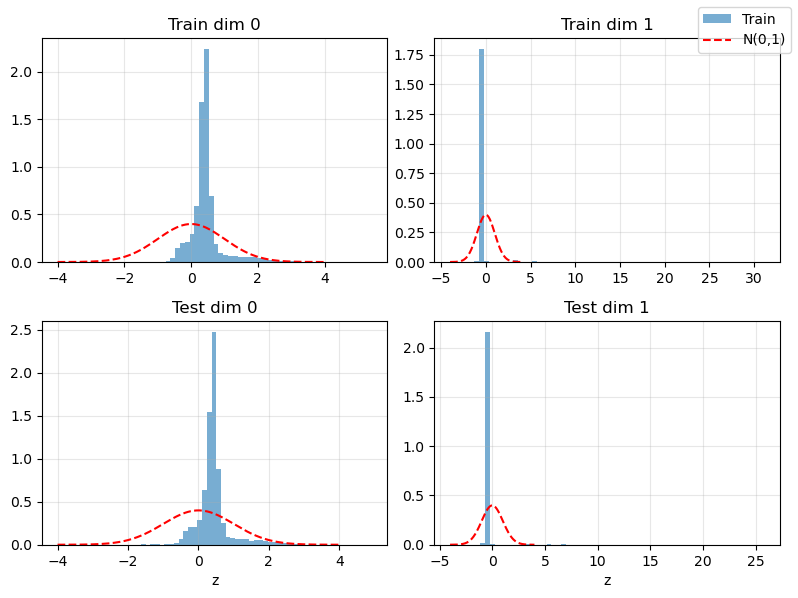

In [62]:
# Marginal histograms with standard normal PDF overlay

D = z_train.shape[1]
xs = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(2, D, figsize=(4 * D, 6), sharex=False)

splits = [("Train", z_train), ("Test", z_test)]

for row, (label, z) in enumerate(splits):
    z_np = z.cpu().numpy()
    for col in range(D):
        ax = axes[row, col] if D > 1 else axes[row]
        data = z_np[:, col]
        ax.hist(data, bins=60, density=True, alpha=0.6, label=f"{label}")
        ax.plot(xs, stats.norm.pdf(xs), "r--", label="N(0,1)")
        ax.set_title(f"{label} dim {col}")
        if row == 1:
            ax.set_xlabel("z")
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()


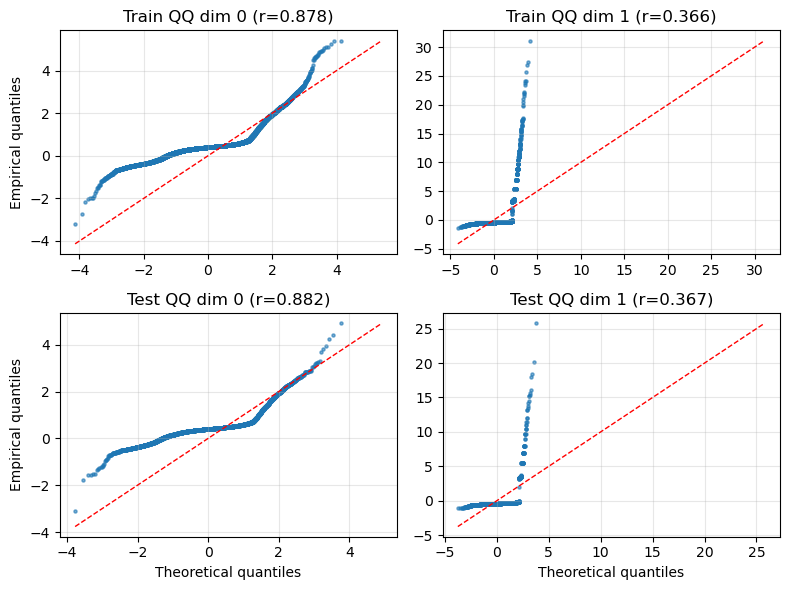

In [63]:
# Normal QQ plots per dimension and split

D = z_train.shape[1]
fig, axes = plt.subplots(2, D, figsize=(4 * D, 6))

splits = [("Train", z_train), ("Test", z_test)]

for row, (label, z) in enumerate(splits):
    z_np = z.cpu().numpy()
    for col in range(D):
        ax = axes[row, col] if D > 1 else axes[row]
        data = z_np[:, col]
        (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
        ax.scatter(osm, osr, s=5, alpha=0.6)
        minv = min(osm.min(), osr.min())
        maxv = max(osm.max(), osr.max())
        ax.plot([minv, maxv], [minv, maxv], "r--", linewidth=1.0)
        ax.set_title(f"{label} QQ dim {col} (r={r:.3f})")
        if row == 1:
            ax.set_xlabel("Theoretical quantiles")
        if col == 0:
            ax.set_ylabel("Empirical quantiles")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Train correlation matrix:
 [[ 1.         -0.00332209]
 [-0.00332209  1.        ]]
Test correlation matrix:
 [[ 1.         -0.03752608]
 [-0.03752608  1.        ]]
Off-diagonal correlation (train): -0.003322092928441809
Off-diagonal correlation (test):  -0.037526077149214285


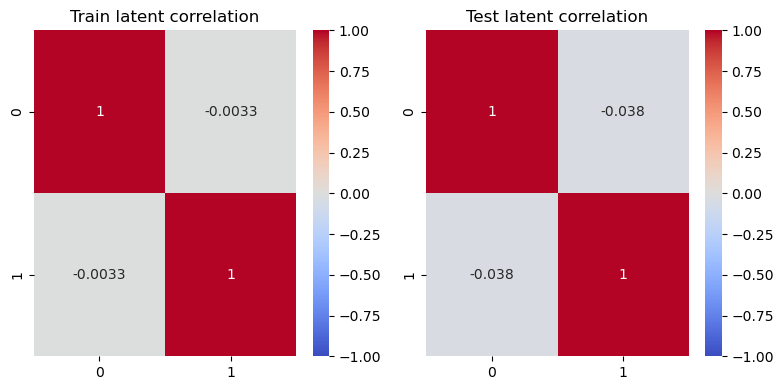

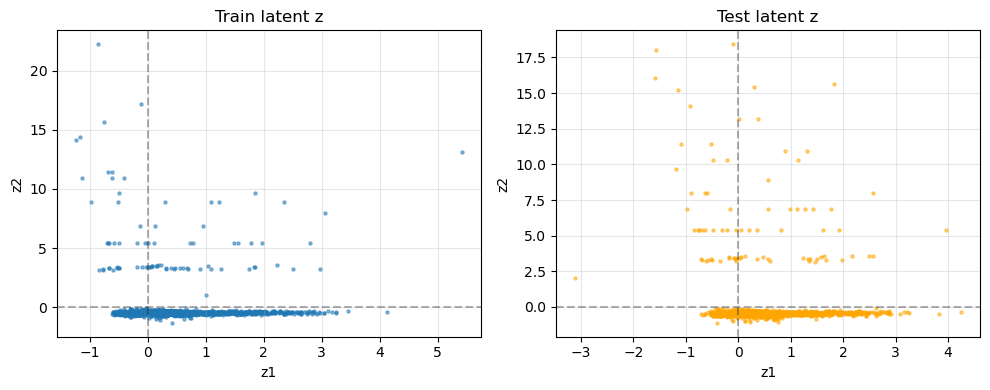


=== Latent normality summary ===
Train off-diagonal correlation should be near 0 if latents are independent.
Test off-diagonal correlation should also be near 0; larger magnitudes indicate residual dependence.


In [64]:
# Correlation matrices, heatmaps, and summary

z_train_np = z_train.cpu().numpy()
z_test_np = z_test.cpu().numpy()

corr_train = np.corrcoef(z_train_np.T)
corr_test = np.corrcoef(z_test_np.T)

print("Train correlation matrix:\n", corr_train)
print("Test correlation matrix:\n", corr_test)
print("Off-diagonal correlation (train):", corr_train[0, 1])
print("Off-diagonal correlation (test): ", corr_test[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.heatmap(corr_train, vmin=-1, vmax=1, annot=True, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Train latent correlation")

sns.heatmap(corr_test, vmin=-1, vmax=1, annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Test latent correlation")

plt.tight_layout()
plt.show()

# Scatter view with both splits
max_points = 5000

def _subsample(z_np, max_points=5000):
    if z_np.shape[0] > max_points:
        idx = np.random.choice(z_np.shape[0], size=max_points, replace=False)
        return z_np[idx]
    return z_np

zt_s = _subsample(z_train_np, max_points)
zs_s = _subsample(z_test_np, max_points)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(zt_s[:, 0], zt_s[:, 1], s=5, alpha=0.5, label="Train")
plt.axhline(0, color="k", linestyle="--", alpha=0.3)
plt.axvline(0, color="k", linestyle="--", alpha=0.3)
plt.title("Train latent z")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(zs_s[:, 0], zs_s[:, 1], s=5, alpha=0.5, color="orange", label="Test")
plt.axhline(0, color="k", linestyle="--", alpha=0.3)
plt.axvline(0, color="k", linestyle="--", alpha=0.3)
plt.title("Test latent z")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Latent normality summary ===")
print("Train off-diagonal correlation should be near 0 if latents are independent.")
print("Test off-diagonal correlation should also be near 0; larger magnitudes indicate residual dependence.")


#### 4. Partial Dependence Plot (Single Feature)

In [65]:
feats = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED',
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

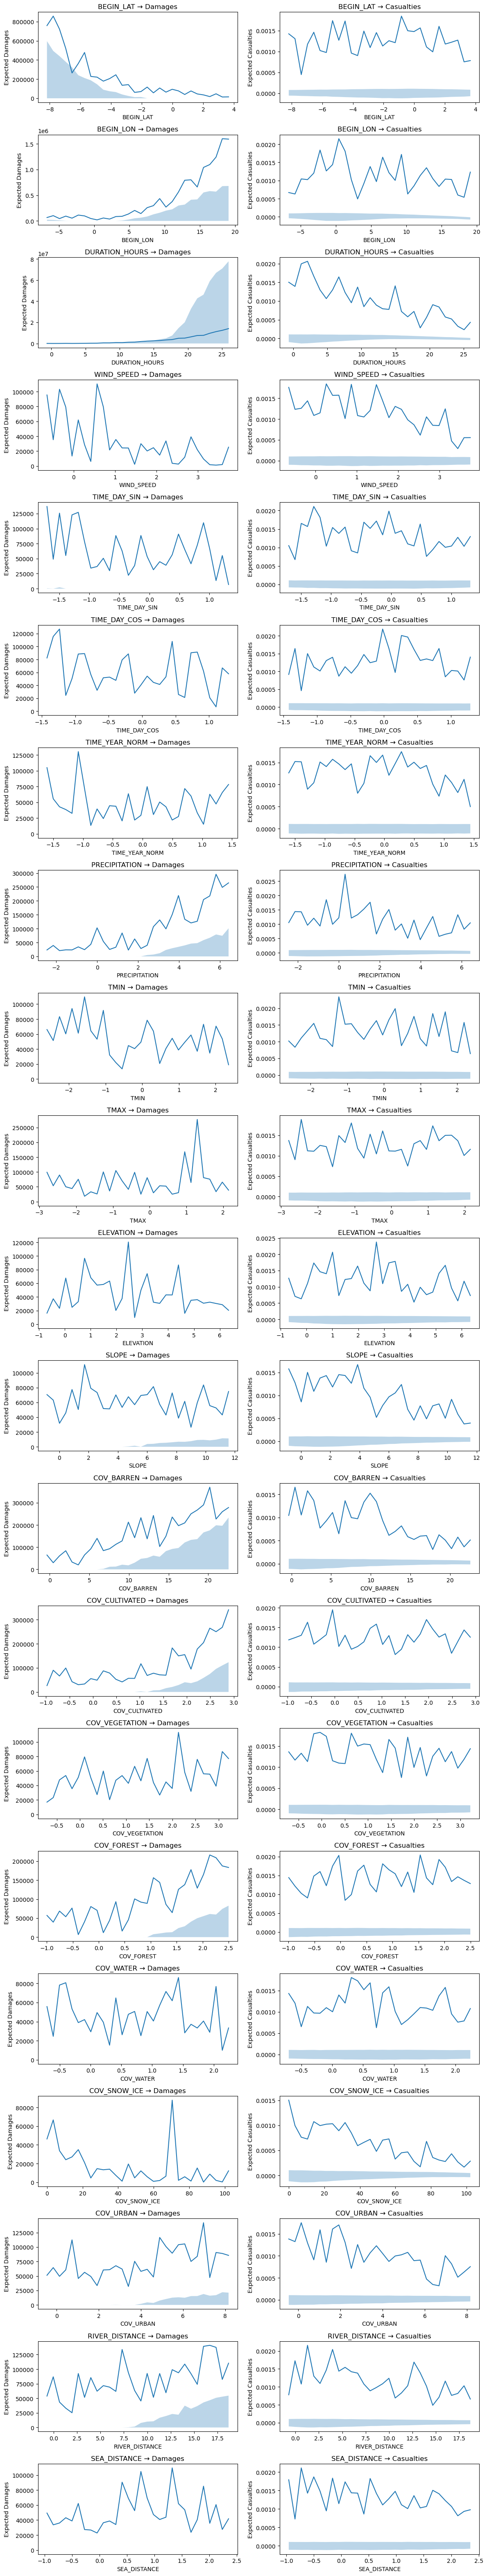

In [66]:
# Partial dependence for all features: damages and casualties, with uncertainty
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    base = X_test.mean(0, keepdim=True)
    means_damages, q05_damages, q95_damages = [], [], []
    means_cas, q05_cas, q95_cas = [], [], []
    for g in grid:
        x = base.clone()
        x[0, k] = g
        s = sample_predictive(flow, x.to(next(flow.parameters()).device))
        means_damages.append(s[:,0].mean())
        q05_damages.append(np.percentile(s[:,0], 5))
        q95_damages.append(np.percentile(s[:,0], 95))
        means_cas.append(s[:,1].mean())
        q05_cas.append(np.percentile(s[:,1], 5))
        q95_cas.append(np.percentile(s[:,1], 95))
    # Damages
    ax = axes[i,0]
    ax.plot(grid, means_damages)
    ax.fill_between(grid, q05_damages, q95_damages, alpha=0.3)
    ax.set_ylabel("Expected Damages")
    ax.set_title(f"{feature} → Damages")
    # Casualties
    ax = axes[i,1]
    ax.plot(grid, means_cas)
    ax.fill_between(grid, q05_cas, q95_cas, alpha=0.3)
    ax.set_ylabel("Expected Casualties")
    ax.set_title(f"{feature} → Casualties")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 5. ICE Curves (Heterogeneous Effects)

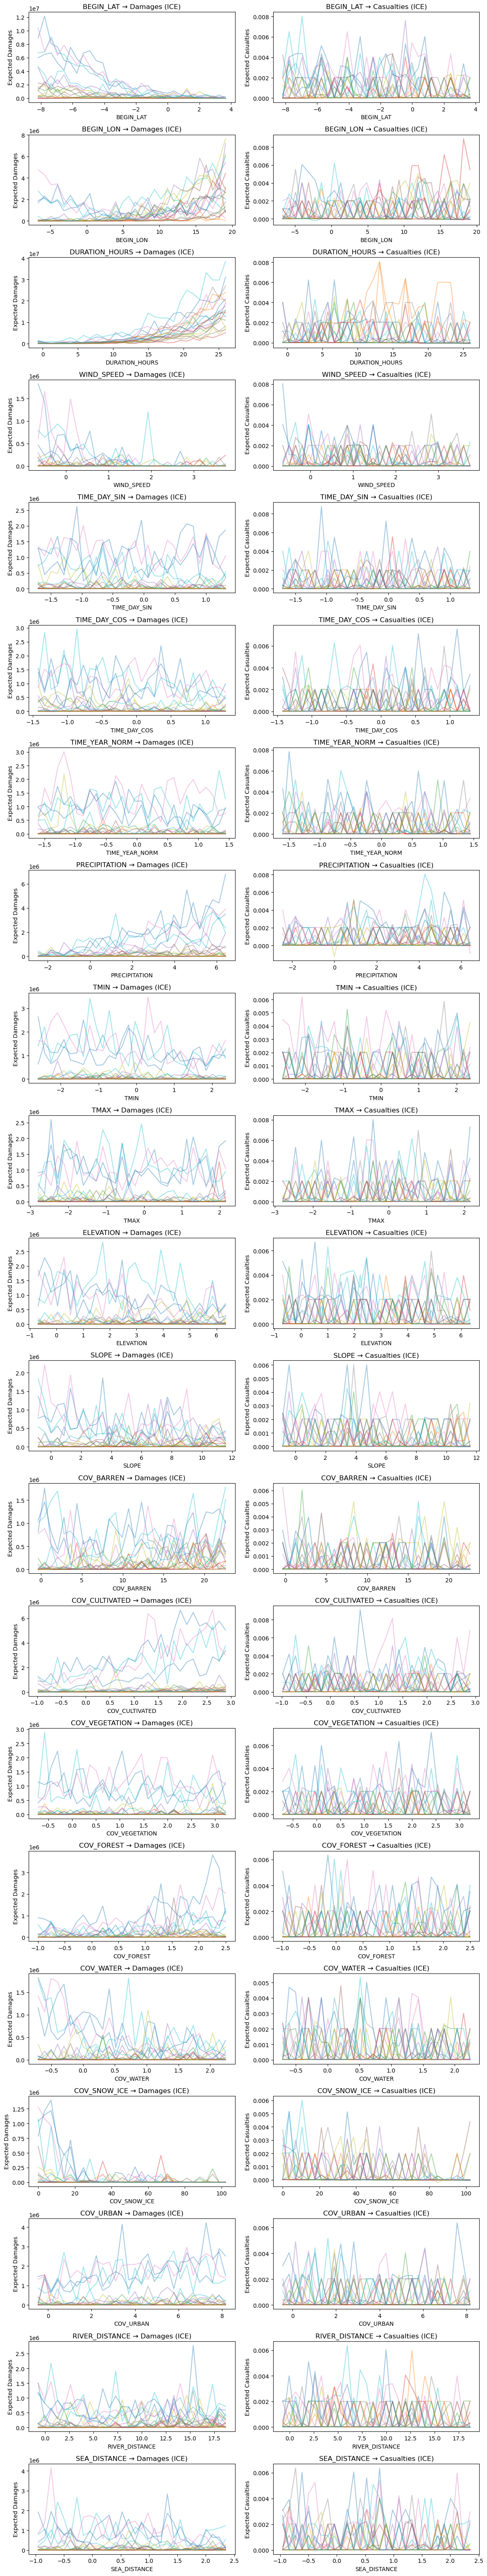

In [67]:
# ICE curves for all features: damages and casualties
n_feats = len(feats)
fig, axes = plt.subplots(n_feats, 2, figsize=(12, 3*n_feats), sharex=False)

n_ice = 20  # number of ICE curves per feature
for i, feature in enumerate(feats):
    k = X_COLS.index(feature)
    grid = np.linspace(X_train[:,k].min(), X_train[:,k].max(), 30)
    # Damages
    for j in range(n_ice):
        base = X_test[j:j+1].clone()
        curve_damages = []
        curve_cas = []
        for g in grid:
            x = base.clone()
            x[0, k] = g
            s = sample_predictive(flow, x.to(next(flow.parameters()).device), 500)
            curve_damages.append(s[:,0].mean())
            curve_cas.append(s[:,1].mean())
        axes[i,0].plot(grid, curve_damages, alpha=0.4)
        axes[i,1].plot(grid, curve_cas, alpha=0.4)
    axes[i,0].set_ylabel("Expected Damages")
    axes[i,0].set_title(f"{feature} → Damages (ICE)")
    axes[i,1].set_ylabel("Expected Casualties")
    axes[i,1].set_title(f"{feature} → Casualties (ICE)")
    for a in axes[i]:
        a.set_xlabel(feature)
plt.tight_layout()
plt.show()


#### 6. Counterfactual Location Comparison

In [68]:
x = X_test[10:11].clone()

urban_low = -2.0
urban_high = 2.0

x_low = x.clone()
x_high = x.clone()

x_low[0,k] = urban_low
x_high[0,k] = urban_high

s_low = sample_predictive(flow, x_low.to(next(flow.parameters()).device))
s_high = sample_predictive(flow, x_high.to(next(flow.parameters()).device))


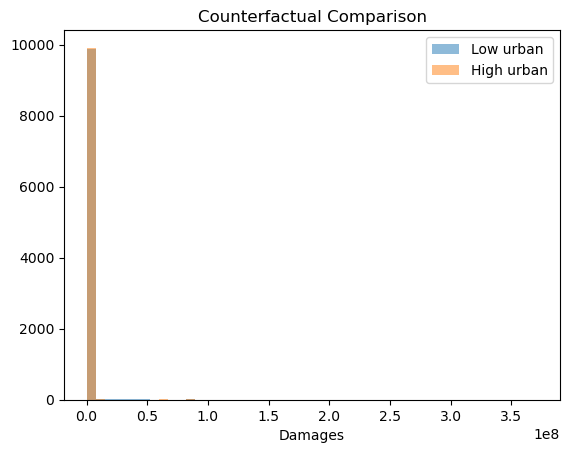

In [69]:
plt.hist(s_low[:,0], bins=50, alpha=0.5, label="Low urban")
plt.hist(s_high[:,0], bins=50, alpha=0.5, label="High urban")
plt.legend()
plt.xlabel("Damages")
plt.title("Counterfactual Comparison")
plt.show()


#### 7. Permutation Feature Importance

In [70]:
def permutation_importance(flow, X, Y, feature_index, n=500):
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]

    with torch.no_grad():
        base = -flow(Xp).log_prob(Yp).mean().item()

    Xp[:,feature_index] = Xp[torch.randperm(len(Xp)),feature_index]

    with torch.no_grad():
        perm = -flow(Xp).log_prob(Yp).mean().item()

    return perm - base


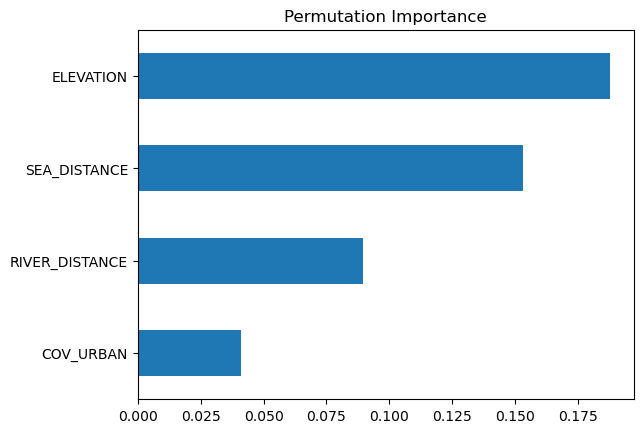

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_test = X_test.to(device)
Y_test = Y_test.to(device)

importances = {}

for f in ["COV_URBAN","ELEVATION","RIVER_DISTANCE","SEA_DISTANCE"]:
    k = X_COLS.index(f)
    importances[f] = permutation_importance(flow, X_test, Y_test, k)

pd.Series(importances).sort_values().plot.barh()
plt.title("Permutation Importance")
plt.show()


#### 8. Calibration / Coverage

In [72]:
def coverage(flow, X, Y, q=90):
    inside = []
    for i in range(200):
        x = X[i:i+1].to(next(flow.parameters()).device)
        s = sample_predictive(flow, x, 2000)
        lo = np.percentile(s, (100-q)/2, axis=0)
        hi = np.percentile(s, 100-(100-q)/2, axis=0)

        y = Y[i].cpu().numpy()
        y = np.expm1(y_scaler.inverse_transform(y.reshape(1,-1)))[0]

        inside.append(np.all((y>=lo)&(y<=hi)))
    return np.mean(inside)


In [73]:
print("90% interval coverage:", coverage(flow, X_test, Y_test))

90% interval coverage: 0.94


### Event simulation

In [74]:
custom_event = {
 'BEGIN_LAT': 35.0,
 'BEGIN_LON': -90.0,
 'DURATION_HOURS': 6,
 'WIND_SPEED': 40,
 'TIME_DAY_SIN': 0.5,
 'TIME_DAY_COS': 0.86,
 'TIME_YEAR_NORM': 0.7,
 'PRECIPITATION': 20,
 'TMIN': 15,
 'TMAX': 28,
 'ELEVATION': 200,
 'SLOPE': 3,
 'COV_BARREN': 0.05,
 'COV_CULTIVATED': 0.40,
 'COV_VEGETATION': 0.30,
 'COV_FOREST': 0.15,
 'COV_WATER': 0.02,
 'COV_SNOW_ICE': 0.00,
 'COV_URBAN': 0.08,
 'RIVER_DISTANCE': 1.5,
 'SEA_DISTANCE': 200
}

In [75]:
x_new = np.array([custom_event[c] for c in X_COLS]).reshape(1,-1)
x_new = x_scaler.transform(x_new)
x_new = torch.tensor(x_new, dtype=torch.float32).to(device)

with torch.no_grad():
    dist = flow(x_new)
    samples = dist.sample((5000,)).squeeze(1)

samples = invert_transform(samples)

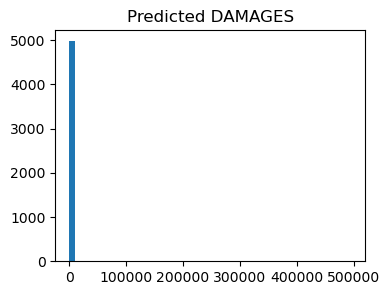

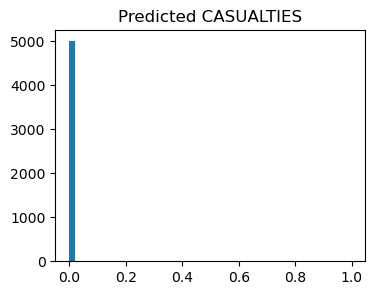

In [76]:
plt.figure(figsize=(4,3))
plt.hist(samples[:,0], bins=50)
plt.title("Predicted DAMAGES")
plt.show()

plt.figure(figsize=(4,3))
plt.hist(samples[:,1], bins=50)
plt.title("Predicted CASUALTIES")
plt.show()


In [77]:
print("Expected damages:", samples[:,0].mean())
print("Median damages:", np.median(samples[:,0]))
print("95% interval:", np.percentile(samples[:,0],[2.5,97.5]))

print("Expected casualties:", samples[:,1].mean())
print("Median casualties:", np.median(samples[:,1]))
print("95% interval:", np.percentile(samples[:,1],[2.5,97.5]))

Expected damages: 482.5439
Median damages: 2.4492045e-05
95% interval: [-0.00118235  0.00043294]
Expected casualties: 0.00041527103
Median casualties: 2.4774405e-05
95% interval: [-7.04011427e-05  1.02004055e-04]


#### Counterfactuals

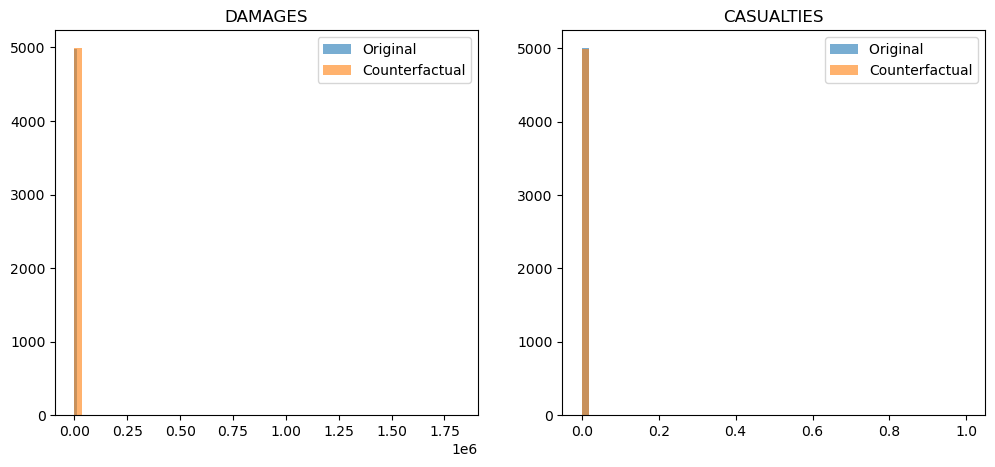

In [78]:
x_cf = x_new.clone()
idx = X_COLS.index("COV_URBAN")
x_cf[0,idx] = (0.5 - x_scaler.mean_[idx]) / x_scaler.scale_[idx]

# Sample again → compare distributions.
with torch.no_grad():
    dist_cf = flow(x_cf)
    samples_cf = dist_cf.sample((5000,)).squeeze(1)

samples_cf = invert_transform(samples_cf)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(samples[:,0], bins=50, alpha=0.6, label="Original")
plt.hist(samples_cf[:,0], bins=50, alpha=0.6, label="Counterfactual")
plt.title("DAMAGES")
plt.legend()
plt.subplot(1,2,2)
plt.hist(samples[:,1], bins=50, alpha=0.6, label="Original ")
plt.hist(samples_cf[:,1], bins=50, alpha=0.6, label="Counterfactual")
plt.title("CASUALTIES")
plt.legend()
plt.show()
